##Histograms of Oriented Gradients
[Dalal, N. and Triggs, B., “Histograms of Oriented Gradients for Human Detection,” IEEE Computer Society Conference on Computer Vision and Pattern Recognition, 2005, San Diego, CA, USA.](https://ieeexplore.ieee.org/document/1467360)

Οι περιγραφείς χαρακτηριστικών του ιστογράμματος προσανατολισμένης κλίσης (HOG) είναι δημοφιλές για την ανίχνευση αντικειμένων. Ο αλγόριθμος έχει τα εξής βήματα:

### Προεπεξεργασία
Στο πρώτο βήμα του αλγορίθμου πραγματοποιείται µία κανονικοποίηση της εικόνας ώστε να µειωθούν οι επιπτώσεις της φωτεινότητάς της στο διάνυσµα των περιγραφικών χαρακτηριστικών.

Στη πράξη χρησιμοποιείται είτε η γάμμα συμπίεση (νόμος ισχύος), είτε ο υπολογισμός της τετραγωνικής ρίζας ή το log κάθε καναλιού χρώματος.

Η ισχύς της **υφής της εικόνας** είναι συνήθως **ανάλογη με** τον **τοπικό φωτισμό της εικόνας**, οπότε αυτή η συμπίεση βοηθά στη μείωση των επιπτώσεων των τοπικών παραλλαγών σκιάς και φωτισμού.

Εάν η εικόνα είναι έγχρωµη η κανονονικοποίηση εφαρµόζεται σε κάθε κανάλι της.

### Υπολογισμός κλίσεων της εικόνας
Στο δεύτερο βήμα υπολογίζονται **οι κλίσεις της εικόνας** (δηλαδή οι πρώτες
παράγωγοι κατά τις διευθύνσεις x και y). Η µάσκα που εξασφάλισε τα καλύτερα αποτελέσµατα για τον υπολογισµό των κλίσεων είναι η **µονοδιάστατη
µάσκα [-1,0,1]**.

Οι κλίσεις παρέχουν πληροφορίες σχετικά µε την ύπαρξη
ακµών και το σχήµα των απεικονιζόµενων αντικειµένων. Σε ορισµένες παραλλαγές του αλγορίθµου, εκτός από τις πρώτες παραγώγους υπολογίζονται και
οι δεύτερες παράγωγοι της εικόνας. Στην περίπτωση έγχρωµων εικόνων
υπολογίζονται οι κλίσεις και στα τρία κανάλια και επιλέγεται η µεγαλύτερη
τιµή.



### Υπολογισμός ιστογράμματος των κλίσεων σε κελιά
Στο τρίτο βήµα, η εικόνα χωρίζεται σε κελιά.

Κάθε κελί (cell) απαρτίζεται από ένα συγκεκριµένο και προκαθορισµένο αριθµό pixels και µπορεί να έχει σχήµα ορθογωνικό (π.χ. 8×8) ή ακτινικό.

Για κάθε κελί δηµιουργείται ένα µονοδιάστατο ιστόγραµµα που καταγράφει τις κλίσεις του συνόλου των pixels που ανήκουν σε αυτό. Η καταγραφή γίνεται σε συγκεκριµένες διευθύνσεις.


Για παράδειγμα, 8×8 κελιά της εικόνας περιέχουν 8x8x3 = 192 pixels.
Η κλίση κάθε τέτοιου κελιού αποτελείται από 2 τιμές (πλάτος και γωνία) για κάθε  pixel δηλαδή 8x8x2 = 128 τιμές.
Κάθε τέτοιο τμήμα με τις 128 τιμές θα αναπαρασταθεί ως ένα 9-bin ιστόγραμμα το οποίο θα αποθηκευθεί σε έναν πίνακα 9 στηλών και θα είναι ισχυρό στο θόρυβο.

![alt text](https://drive.google.com/uc?id=1lc8odEpEpIzZfX83cFcJBOCWY1afhOhG)

Ειδικότερα, ανάλογα µε τον προκαθορισµένο αριθµό διαστηµάτων που χρησιµοποιούνται δηµιουργείται ένα ιστόγραµµα µε συγκεκριµένους προσανατολισµούς.

Το εύρος του ιστογράµµατος µπορεί να είναι από $0^o-180^ο$
(µη προσηµασµένη κλίση: unsigned gradient) ή από $0^ο-360^ο$ (προσηµασµένη κλίση: signed gradient). Για παράδειγµα, εάν ο χώρος $0^ο-180^ο$
υποδιαιρεθεί ανά $20^ο$, δηµιουργείται ένα ιστόγραµµα µε εννιά πιθανές διευθύνσεις κλίσεων, ενώ αν διαιρεθεί ο χώρος $0^ο-360^ο$, δηµιουργείται ένα ιστόγραµµα µε 18 πιθανές διευθύνσεις.

Εμπειρικά έχει αποδειχθεί ότι οι µη προσηµασµένες κλίσεις λειτουργούν καλύτερα από τις προσηµασµένες κλίσεις για την ανίχνευση πεζών.

Το επόμενο βήμα είναι να δημιουργήσετε ένα ιστόγραμμα διαβαθμίσεων σε αυτά τα κελιά 8×8. Το ιστόγραμμα περιέχει 9 bins που αντιστοιχούν στις γωνίες 0, 20, 40 … 160. Το παρακάτω σχήμα απεικονίζει τη διαδικασία. Εξετάζουμε το μέγεθος και την κατεύθυνση της κλίσης του ίδιου κελιού 8×8 όπως στο προηγούμενο σχήμα.

Για κάθε pixel υπολογίζεται η διεύθυνση (ή και η φορά) της κλίσης, και αυτή ψηφίζει µε κάποιο βάρος για το αντίστοιχο διάστηµα στο οποίο ανήκει.

Ας εστιάσουμε πρώτα στο pixel που περιβάλλεται με μπλε χρώμα. Έχει γωνία (κατεύθυνση) 80 μοιρών και μέγεθος 2. Άρα προσθέτει 2 στον 5ο κάδο. Η κλίση στο εικονοστοιχείο που περιβάλλεται με το κόκκινο έχει γωνία 10 μοιρών και μέγεθος 4. Δεδομένου ότι οι 10 μοίρες είναι στα μισά του "δρόμου" μεταξύ 0 και 20, η ψήφος από το εικονοστοιχείο χωρίζεται ομοιόμορφα στα δύο δοχεία.

![](https://drive.google.com//uc?id=1mCnmWIL1T98W7aPLvbasxvEwMWkNL4iH)



Εάν η γωνία είναι μεγαλύτερη από 160 μοίρες, είναι μεταξύ 160 και 180, και ξέρουμε ότι η γωνία περιτυλίσσεται κάνοντας 0 και 180 ισοδύναμα. Στο παρακάτω παράδειγμα λοιπόν, το pixel με γωνία 165 μοιρών συνεισφέρει αναλογικά στο bin 0 μοιρών και στο bin 160 μοιρών.


Για $θ=165^o$, το μέτρο θα πρέπει να κατανεμηθεί ανάλογα με την απόσταση της φάσης από τα κέντρα γειτονικών bins. Από τις $180^ο$ το $θ$ απέχει $15^ο$ άρα στο bin αναλογούν $\frac{15}{20}=\frac{3}{4}$ του μέτρου ($85 \cdot\frac{3}{4})=63,75‬$) ενώ στο επόμενο bin αναλογούν τα $\frac{5}{20}= \frac{1}{4}$ (($85 \cdot\frac{1}{4})=21,25‬$))

![alt text](https://drive.google.com/uc?id=1tgfxD0KAg-UmE1FVC9F3HnN644lnYQ98)

Οι συνεισφορές όλων των pixel στα κελιά 8 × 8 προστίθενται για τη δημιουργία του ιστογράμματος 9-bin.

![alt text](https://drive.google.com/uc?id=1zgFkfQVzIKe3Q2gFt4rgPuL_9MVq8vev)

Το ιστόγραμμα του κελιού όπως προέκυψε μετά από αυτήν τη διαδικασία, φαίνεται να έχει πολλές τιμές κοντά σε 0 και 180 μοίρες, κάτι που είναι απλώς ένας άλλος τρόπος για να πούμε ότι οι κλίσεις του κελιού δείχνουν είτε πάνω είτε κάτω.

### Κανονικοποίηση 16×16 Block

Στο τέταρτο βήµα, τα ιστογράµµατα που έχουν προκύψει κανονικοποιούνται
για µεγαλύτερη ανοχή σε σκιάσεις και έντονες αλλαγές φωτεινότητας.

Οι κλίσεις μιας εικόνας είναι ευαίσθητες στην φωτεινότητα. Αν, για παράδειγμα, μειώσουμε κατά το ήμισυ το πλάτος των κλίσεων (/2 όλων των τιμών), οι τιμές των ιστογραμμάτων θα μειωθούν και αυτές στο ήμισυ. Γιαυτό οδηγούμαστε στην κανονικοποίηση ώστε να αποφύγουμε τις διακυμάνσεις φωτισμού.

*(Παράδειγμα κανονικοποίησης RGB διανύσματος: έστω διάνυσμα $v_1=[ 128, 64, 32 ]$ Εφαρμόζοντας L2 norm θα έχουμε $[0.87, 0.43, 0.22]$. Έστω διάνυσμα $v_2=2\cdot v_1=[ 256, 128, 64 ]$. Εφαρμόζοντας L2 norm στο $v_2$ θα πάρουμε  $
[0.87, 0.43, 0.22]$ το οποίο είναι ίδιο με το κανονικοποιημένο διάνυσμα του $v_1$. Άρα με την κανονικοποίηση αφαιρείται η κλιμάκωση). Οπότε θα μπορούσαμε να ομαλοποιήσουμε το ιστόγραμμα 9 × 1 με τον ίδιο τρόπο που ομαλοποιήσαμε το διάνυσμα 3 × 1*

![](https://drive.google.com/uc?id=1EyPRgx2pwBRw3X7QzvQ0MhMJUUasZx-W)

Αντί να ομαλοποιήσει το ιστόγραμμα 9 × 1 που προέκυψε από το κάθε κελί ο αλγόριθμος HOG ομαλοποιεί ένα μεγαλύτερο μέγεθος μπλοκ 16 × 16. Ένα μπλοκ 16 × 16 έχει 4 ιστογράμματα τα οποία μπορούν να συνδυαστούν για να σχηματίσουν ένα  διανύσματος 36 x 1 το οποίο και ομαλοποιείται. Στη συνέχεια, το παράθυρο μετακινείται κατά 8 εικονοστοιχεία και υπολογίζεται το επόμενο κανονικοποιημένο διάνυσμα 36 × 1 σε αυτό το παράθυρο και η διαδικασία επαναλαμβάνεται μέχρι να ληφθούν όλα τα μπλοκς.

Οπότε κάθε κελί μοιράζεται μεταξύ πολλών μπλοκ, αλλά οι ομαλοποιήσεις του εξαρτώνται από το μπλοκ και επομένως είναι διαφορετικές. Έτσι, το κελί εμφανίζεται αρκετές φορές στον περιγραφέα εξόδου με διαφορετικές ομαλοποιήσεις. Αυτό μπορεί να φαίνεται περιττό, αλλά βελτιώνει την απόδοση.

### Υπολογισμός του διανύσματος χαρακτηριστικών HOG (HOG feature vector)
Το τελικό βήμα συλλέγει τους περιγραφείς HOG από όλα τα μπλοκ 16x16  σε ένα διάνυσμα το οποίο μπορεί να χρησιμοποιηθεί σε διάφορες εφαρμογές εικόνας (ταξινόμηση, ανίχνευση αντικειμένων,...).

Στην παραπάνω εικόνα παρατηρούμε ότι έχουμε 7x15=105 μπλοκς Κάθε μπλοκ 16x16 αναπαρίσταται από ένα διάνυσμα ιστογράμμτος 36x1. Οπότε για την συγκεκριμένη εικόνα προκύπτει ένα τελικό διάνυσμα διάστασης  105x36x1= 3780x1

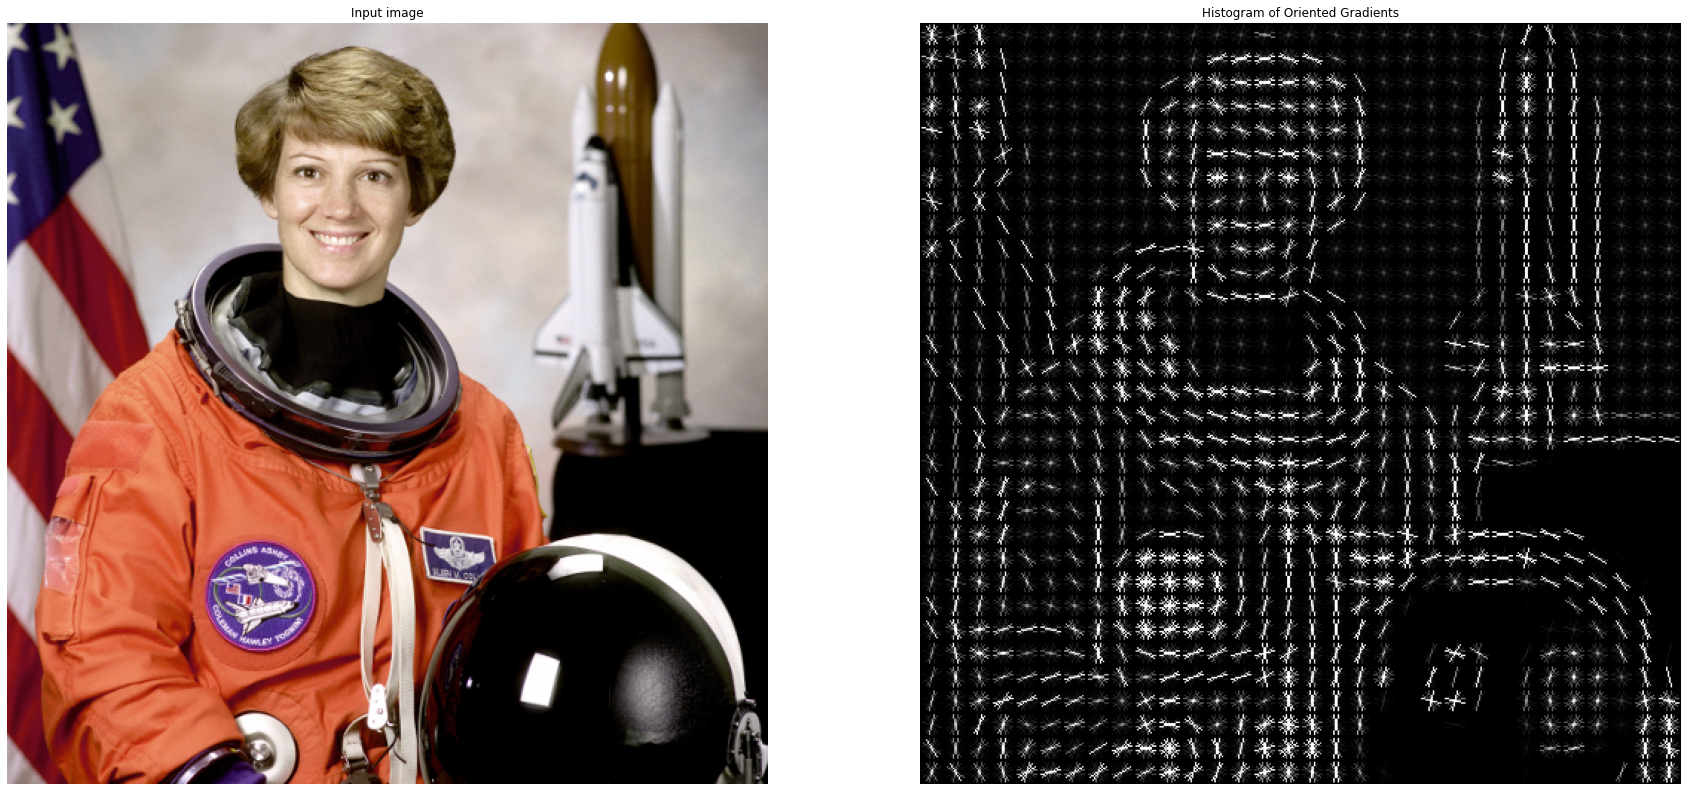

[0.50388675 0.38088212 0.09937447 ... 0.1058451  0.0780902  0.50577708]


In [ ]:
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import data, exposure


image = data.astronaut()


fd, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1), block_norm="L2", feature_vector="True", visualize=True, multichannel=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()
print(fd)